# 〰 LAB TOOLS &mdash; Interpolação e Suavização

---
Copyright (C) 2026 Roberto Baginski Batista Santos - Prof.Baginski@gmail.com

Este programa é um software livre; você pode redistribuí-lo e/ou
modificá-lo sob os termos da Licença Pública Geral GNU como publicada
pela Free Software Foundation; tanto a versão 3 da Licença, ou
(a seu critério) qualquer versão posterior.

Este programa é distribuído na expectativa de que seja útil,
mas SEM NENHUMA GARANTIA; sem mesmo a garantia implícita de
COMERCIALIZAÇÃO ou de ADEQUAÇÃO A QUALQUER PROPÓSITO EM PARTICULAR.
Veja a Licença Pública Geral GNU para mais detalhes.

Você deve ter recebido uma cópia da Licença Pública Geral GNU junto
com este programa. Se não, veja https://www.gnu.org/licenses/gpl-3.0.html.

---
Esta ferramenta determina **funções de interpolação e de suavização** para um conjunto $\{(x_1,y_1),\cdots,(x_i,y_i),\cdots,(x_N,y_N)\}$ de $N$ pontos experimentais. A interpolação e a suavização são realizadas usando métodos implementados na biblioteca SciPy.

---
### Interpolação
A interpolação é o processo pelo qual uma função $f(x)$ é ajustada exatamente aos $N$ pontos experimentais, isto é, $f(x_i)=y_i$ para todo ponto $(x_i,y_i)$ do conjunto de pontos experimentais.

A interpolação pode ser realizada com um **polinômio de Lagrange** de grau $N-1$. Porém, como polinômios de grau elevado produzem oscilações exageradas perto dos pontos extremos (fenômeno de Runge), este método costuma ser usado apenas para conjuntos de poucos pontos. Uma alternativa melhor é a interpolação com **splines cúbicas**, que são funções polinomiais de grau $3$ unidas nos pontos experimentais para criar uma curva suave. Há vários tipos de splines cúbicas, dependendo das condições de contorno escolhidas.

**Métodos para interpolação:**

1. Polinômio de Lagrange
2. Spline cúbica (not-a-knot)
3. Spline cúbica (natural)
4. Spline cúbica (restrita ou *clamped*)
5. Spline cúbica (periódica)
6. Spline cúbica (monotônica)

---
### Suavização (smoothing)
A suavização é um método usado principalmente para dados ruidosos, em que o objetivo é determinar uma função $f(x)$ que aproxime suavemente o conjunto de pontos experimentais, sem que seja obrigatório passar pelos pontos, como na interpolação. O objetivo é equilibrar o grau de aproximação e a suavidade da curva, usando um método de mínimos quadrados com penalidade. Para suavização, usamos funções **B-splines** e os métodos de otimização podem ser escolhidos entre GCV (Generalized Cross-Validation) ou FITPACK.

**Métodos para suavização:**

1. B-spline (GCV)
2. B-spline (FITPACK)

Os dados podem conter incertezas na variável dependente, que dão origem a pesos usados no método de mínimo quadrados.

---
**Como usar:**
Execute a **Célula 1** — a interface aparece logo abaixo.  

---
### Formatos de arquivo aceitos

| Formato | Extensão |
|---|---|
| XLSX - Planilha do Excel | `.xlsx` |
| CSV - Valores separados por vírgula | `.csv` `.txt` |


Nomes de grandeza com sinais diacríticos como **acentos, cedilha ou til** (`posição`, `força`, `ângulo` ou `pressão`, por exemplo) são aceitos. Há campos na interface gráfica para indicar os rótulos (nomes ou símbolos) das grandezas e suas unidades.  

No formato `XLSX`, cada grandeza deve ocupar uma coluna da planilha e os valores numéricos podem usar `.` ou `,` como separador decimal.

Para indicar os rótulos (nomes ou símbolos das grandezas) e as unidades das grandezas medidas, use as palavras-chave `#rótulos:` e `#unidades:` seguidas de valores separados por `,` ou por `;`.

As informações sobre rótulos e unidades devem estar obrigatoriamente nas células `A1` e `A2`, respectivamente, antes das linhas que contêm os valores numéricos dos dados:

|   |    A                         | B       |
|:--|:------                       |:--------|
| 1 | #rótulos: Tempo, Posição     |         |     
| 2 | #unidades: s, m              |         |    
| 3 | 10.0                         | 15.2    |     

No formato `CSV`, os valores devem ser separados por `,` ou por `;`. Os valores numéricos podem usar `.` ou `,` como separador decimal. Se usar `,` como separador decimal, use `;` como separador de valores, para evitar ambiguidade.

Os rótulos e as unidades das grandezas medidas podem ser informados em linhas de comentários (iniciadas com `#`), antes das linhas que contêm os valores numéricos dos dados.

Para indicar rótulos e unidades, use as palavras-chave `#rótulos:` e `#unidades:`no início das linhas, seguidas de valores separados por `,` ou por `;`:

```
 #rótulos: Tempo, Posição
 #unidades: s, m
 10.0, 15.2
 ...
```
Se estas linhas estiverem ausentes, rótulos e unidades poderão ser
preenchidas manualmente em campos presentes na interface gráfica.

---
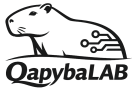

**https://github.com/rbaginski/QapybaLAB**

In [ ]:
#@title Execute esta célula para abrir a ferramenta **LAB TOOLS &mdash; Interpolação e Suavização**
# ── Célula 1: interpolação e suavização ───────────────────────────────
# A ferramenta foi especificada pelo licenciante, incluindo modelos, métodos,
# pacotes a serem usados e linhas gerais da inteface gráfica, mas a maior parte
# do código, especialmente as funções para leitura de arquivos e para a
# interface gráfica, foi escrita usando o modelo Claude Sonnet 4.6.
# O código gerado foi inspecionado e sofreu diversas alterações e correções
# realizadas pelo licenciante e pelo modelo Gemini 3.5-flash.

import math, io, re, base64, unicodedata, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as w
from IPython.display import display, HTML, clear_output

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ══════════════════════════════════════════════════════════════════
#  ESTILOS CSS  (mesma convenção da suíte QapybaLAB)
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<style>
.sec{font-weight:700;font-size:.75rem;letter-spacing:.08em;color:#3b5bdb;
  text-transform:uppercase;margin:13px 0 3px;}
.rcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.gcard{background:#f0fff4;border-left:4px solid #2f9e44;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.wcard{background:#fff9db;border-left:4px solid #e67700;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.ecard{background:#fff0f0;border-left:4px solid #c92a2a;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.icard{background:#f3f0ff;border-left:4px solid #7048e8;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.88rem;}
.poly-t{border-collapse:collapse;font-size:.83rem;margin:6px 0;width:100%;}
.poly-t th{background:#3b5bdb;color:#fff;padding:5px 10px;text-align:left;}
.poly-t td{padding:4px 10px;border-bottom:1px solid #e0e4f0;font-family:monospace;}
.poly-t tr:nth-child(even) td{background:#f0f4ff;}
</style>
"""))

# ══════════════════════════════════════════════════════════════════
#  UTILITÁRIOS
# ══════════════════════════════════════════════════════════════════
def nome_para_arquivo(nome):
    nfd = unicodedata.normalize("NFD", nome)
    return "".join(c for c in nfd
                   if unicodedata.category(c) != "Mn").replace(" ", "_")

def fmt_sig(v, sig=5):
    v = float(v)
    if not math.isfinite(v) or v == 0:
        return str(v)
    d = int(math.floor(math.log10(abs(v)))) - (sig - 1)
    return (f"{round(v,-d):.{max(0,-d)}f}" if d >= 0 else f"{v:.{-d}f}")

def eh_numero(s):
    try:
        float(str(s).replace(',', '.'))
        return True
    except (ValueError, AttributeError):
        return False

def parse_rotulo_unidade(texto):
    texto = str(texto).strip()
    m = re.match(r'^(.*?)\s*\(([^()]*)\)\s*$', texto)
    if m and m.group(1).strip():
        return m.group(1).strip(), m.group(2).strip()
    return texto, ''

def extrair_metadados(linha_str):
    s = str(linha_str).strip()
    if not s.startswith('#'): return None, None
    s = s.lstrip('#').strip()
    if ':' not in s: return None, None
    chave, resto = s.split(':', 1)
    chave = chave.strip().lower()
    valores = [v.strip() for v in re.split(r'[,\t]', resto) if v.strip() != '']
    if not valores: return None, None
    if chave in ('unidades', 'unidade', 'units', 'unit'):
        return 'unidades', valores
    return None, None

def h(tag, content, **attrs):
    a = " ".join(f'{k.rstrip("_")}="{v}"' for k, v in attrs.items())
    return f"<{tag} {a}>{content}</{tag}>"

def card(s, c="rcard"):
    return f'<div class="{c}">{s}</div>'

def sec_html(texto, estilo=""):
    extra = f' style="{estilo}"' if estilo else ""
    return f'<div class="sec"{extra}>{texto}</div>'

def titulo_secao(texto, estilo=""):
    return w.HTML(sec_html(texto, estilo))

# ══════════════════════════════════════════════════════════════════
#  LEITURA DE ARQUIVO  (idêntica ao Ajuste de Curvas)
# ══════════════════════════════════════════════════════════════════
def detectar_sep(texto):
    cnt = {",": 0, ";": 0, "\t": 0}
    for l in texto.splitlines()[:10]:
        s = l.strip()
        if not s or s.startswith("#"): continue
        for sep in cnt: cnt[sep] += s.count(sep)
    best = max(cnt, key=cnt.get)
    return best if cnt[best] > 0 else " "

def ler_texto(texto, sep, cx, cy, csy, tem_sy):
    linhas = [l for l in texto.splitlines()
              if l.strip() and not l.strip().startswith("#")]
    if not linhas: return None, ["Arquivo sem dados."]
    tok = (linhas[0].split(sep) if sep != " " else linhas[0].split())
    tem_cab = any(not t.strip().replace(",", "").replace(".", "", 1)
                  .lstrip("-").isdigit() for t in tok if t.strip())
    if tem_cab: linhas = linhas[1:]
    pontos = []; erros = []
    for i, linha in enumerate(linhas, 1):
        ps = ([p.strip() for p in linha.split(sep)] if sep != " " else linha.split())
        try:
            def v(idx): return float(ps[idx].replace(',', '.'))
            x  = v(cx)
            y  = v(cy)
            sy = v(csy) if tem_sy and csy is not None and csy < len(ps) else None
            if tem_sy and sy is not None and sy <= 0:
                raise ValueError(f"σy={sy}≤0")
            pontos.append((x, y, sy))
        except Exception as e:
            erros.append(f"Linha {i}: {e}")
    return (pontos or None), erros

def ler_xlsx(conteudo_bytes, cx, cy, csy, tem_sy):
    try:
        import openpyxl
    except ImportError:
        return None, ["openpyxl não instalado. Execute: !pip install openpyxl"]
    try:
        wb = openpyxl.load_workbook(io.BytesIO(conteudo_bytes), data_only=True)
        ws = wb.active
    except Exception as e:
        return None, [f"Erro ao abrir XLSX: {e}"]
    linhas = []
    for row in ws.iter_rows(values_only=True):
        cells = [str(c).strip() if c is not None else '' for c in row]
        linha_str = '\t'.join(cells).strip()
        if not linha_str or linha_str.startswith('#'): continue
        linhas.append(cells)
    if not linhas: return None, ["Arquivo XLSX sem dados."]
    tem_cab = any(c and not eh_numero(c) for c in linhas[0] if c)
    if tem_cab: linhas = linhas[1:]
    pontos = []; erros = []
    for i, cells in enumerate(linhas, 1):
        try:
            def v(idx):
                s = cells[idx].replace(',', '.') if idx < len(cells) else ''
                return float(s)
            x  = v(cx)
            y  = v(cy)
            sy = v(csy) if tem_sy and csy is not None else None
            if tem_sy and sy is not None and sy <= 0:
                raise ValueError(f"σy={sy}≤0")
            pontos.append((x, y, sy))
        except Exception as e:
            erros.append(f"Linha {i}: {e}")
    return (pontos or None), erros

# ══════════════════════════════════════════════════════════════════
#  CABEÇALHO
# ══════════════════════════════════════════════════════════════════
cabecalho = w.HTML(r'''
<div style="background: linear-gradient(135deg, #004587 0%, #00AB45 80%, #006EAB 100%);
            padding: 14px 20px; border-radius: 10px; color: white;
            font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 12px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.15);">
  <div style="font-size: 13px; letter-spacing: 3px; opacity: 0.85; font-weight: 600;">QapybaLAB &mdash; LAB TOOLS</div>
  <div style="font-size: 26px; font-weight: 700; margin-top: 2px;">〰 Interpolação e Suavização</div>
</div>
''')
display(w.VBox([cabecalho]))

# ══════════════════════════════════════════════════════════════════
#  RÓTULOS / UNIDADES
# ══════════════════════════════════════════════════════════════════
display(titulo_secao('⚙ Configuração'))
ES = {"description_width": "130px"}
FL = w.Layout(width="100%")
WA = w.Layout(width="99%", min_height="200px", font_family="monospace")

wlx = w.Text(value="x", description="Rótulo de x:", style=ES)
wux = w.Text(value="",  description="Unidade de x:", style=ES, placeholder="ex: s, m, V")
wly = w.Text(value="y", description="Rótulo de y:", style=ES)
wuy = w.Text(value="",  description="Unidade de y:", style=ES, placeholder="ex: m, A, N")
display(w.HBox([
    w.VBox([wlx, wux], layout=w.Layout(width="48%")),
    w.VBox([wly, wuy], layout=w.Layout(width="48%")),
], layout=FL))

# ══════════════════════════════════════════════════════════════════
#  MODO: INTERPOLAÇÃO vs. SUAVIZAÇÃO
# ══════════════════════════════════════════════════════════════════
display(titulo_secao('🔧 Método'))
wmodo = w.ToggleButtons(
    options=["〰 Interpolação", "〜 Suavização"],
    value="〰 Interpolação",
    layout=w.Layout(margin="4px 0 8px"))
display(wmodo)

METODOS_INTERP = [
    "Lagrange",
    "Spline cúbica (not-a-knot)",
    "Spline cúbica (natural)",
    "Spline cúbica (restrita)",
    "Spline cúbica (periódica)",
    "Spline cúbica (monotônica)",
]

wmetodo_interp = w.Dropdown(
    options=METODOS_INTERP,
    value="Spline cúbica (not-a-knot)",
    description="Método:", style=ES, layout=w.Layout(width="360px"))

wbc_label = w.HTML('<small style="color:#555">Derivadas prescritas nas extremidades:</small>')
wbc_esq = w.FloatText(value=0., description="dy/dx em x₀:", style=ES,
                       layout=w.Layout(width="240px"))
wbc_dir = w.FloatText(value=0., description="dy/dx em xₙ:", style=ES,
                       layout=w.Layout(width="240px"))
painel_clamped = w.VBox([wbc_label, w.HBox([wbc_esq, wbc_dir])])
painel_clamped.layout.display = "none"

painel_interp = w.VBox([wmetodo_interp, painel_clamped])

METODOS_SUAV = [
    "B-spline (GCV)",
    "B-spline (FITPACK)",
]
wmetodo_suav = w.Dropdown(
    options=METODOS_SUAV,
    value="B-spline (GCV)",
    description="Método:", style=ES, layout=w.Layout(width="340px"))

painel_suav = w.VBox([wmetodo_suav])

painel_metodo = w.VBox([painel_interp])
display(painel_metodo)

def _on_metodo_interp(change):
    m = change["new"]
    painel_clamped.layout.display = "" if m == "Spline cúbica (restrita)" else "none"
wmetodo_interp.observe(_on_metodo_interp, names="value")

def _on_modo(change):
    v = change["new"]
    if "Interpolação" in v:
        painel_interp.layout.display = ""
        painel_suav.layout.display   = "none"
        painel_metodo.children = (painel_interp,)
    else:
        painel_suav.layout.display   = ""
        painel_interp.layout.display = "none"
        painel_metodo.children = (painel_suav,)
wmodo.observe(_on_modo, names="value")

# ══════════════════════════════════════════════════════════════════
#  INCERTEZAS
# ══════════════════════════════════════════════════════════════════
display(titulo_secao('📏 Incertezas'))
wtem_sy = w.Checkbox(value=False,
    description="Incerteza em y (σy) — usada como peso na suavização",
    indent=False, layout=w.Layout(width="520px"))
display(wtem_sy)

# ══════════════════════════════════════════════════════════════════
#  DADOS
# ══════════════════════════════════════════════════════════════════
display(titulo_secao('📋 Dados'))
wfonte = w.ToggleButtons(
    options=["✏️ Digitar", "📂 Carregar arquivo"],
    value="✏️ Digitar",
    layout=w.Layout(margin="4px 0 10px"))
display(wfonte)

digitar_hint = w.HTML("")
wtexto = w.Textarea(placeholder="0.0  1.0\n1.0  2.7\n2.0  7.4\n...", layout=WA)
painel_digitar = w.VBox([digitar_hint, wtexto])

warq = w.FileUpload(
    accept=".csv,.tsv,.txt,.xlsx,.xls",
    multiple=False,
    description="Selecionar arquivo (CSV/TXT/XLSX)",
    layout=w.Layout(width="auto"))
sep_label = {",": "Vírgula ','", ";": "Ponto e vírgula ';'",
             "\t": "Tabulação TAB", " ": "Espaço(s)"}
sep_inv = {v: k for k, v in sep_label.items()}
wsep = w.Dropdown(options=list(sep_label.values()),
                  description="Separador:", style=ES, layout=w.Layout(width="280px"))
wsep_box  = w.HBox([wsep])
warq_tipo = w.HTML("")
warq_preview  = w.HTML("")
warq_rotulos  = w.HTML("")
ncol_box  = w.HBox([], layout=FL)
painel_arquivo = w.VBox([warq, warq_tipo, wsep_box, warq_preview, ncol_box, warq_rotulos])

arq_estado = {"modo": None, "texto": "", "bytes": None, "n_col": 1,
              "cabecalho": None, "meta": {}}

def _atualizar_rotulos_arquivo(*_):
    if arq_estado["modo"] is None:
        warq_rotulos.value = ""; return
    meta = arq_estado.get("meta") or {}
    cab  = arq_estado.get("cabecalho")
    dds  = {dd._key: int(dd.value) - 1 for dd in ncol_box.children}
    cx   = dds.get("cx", 0); cy = dds.get("cy", 1)
    rot_x = rot_y = uni_x = uni_y = None
    unidades = meta.get("unidades")
    if cab:
        if cx < len(cab) and cab[cx]:
            rot_x, u = parse_rotulo_unidade(cab[cx])
            if u: uni_x = u
        if cy < len(cab) and cab[cy]:
            rot_y, u = parse_rotulo_unidade(cab[cy])
            if u: uni_y = u
    if unidades and len(unidades) >= 2:
        if uni_x is None: uni_x = unidades[0]
        if uni_y is None: uni_y = unidades[1]
    achou = False
    if rot_x: wlx.value = rot_x; achou = True
    if uni_x is not None: wux.value = uni_x; achou = True
    if rot_y: wly.value = rot_y; achou = True
    if uni_y is not None: wuy.value = uni_y; achou = True
    if achou:
        partes = []
        if rot_x: partes.append(f"x = {rot_x}" + (f" ({uni_x})" if uni_x else ""))
        if rot_y: partes.append(f"y = {rot_y}" + (f" ({uni_y})" if uni_y else ""))
        warq_rotulos.value = card(
            f'🏷 Rótulos/unidades detectados: {" · ".join(partes)}', "icard")
    else:
        warq_rotulos.value = ""

def _rebuild_col_dropdowns(*_):
    n = arq_estado["n_col"]
    if n < 1: return
    opts  = [str(i + 1) for i in range(n)]
    lx_   = wlx.value or "x"; ly_ = wly.value or "y"
    campos = [(f"Col. {lx_}:", "cx", "1"),
              (f"Col. {ly_}:", "cy", "2")]
    if wtem_sy.value:
        campos.append((f"Col. σ({ly_}):", "csy",
                       "3" if n >= 3 else opts[-1]))
    dds = []
    for lbl, key, default in campos:
        dd = w.Dropdown(options=opts,
                        value=default if default in opts else opts[0],
                        description=lbl, style=ES, layout=w.Layout(width="200px"))
        dd._key = key
        dd.observe(_atualizar_rotulos_arquivo, names="value")
        dds.append(dd)
    ncol_box.children = tuple(dds)
    _atualizar_rotulos_arquivo()

def _on_upload(change):
    if not warq.value: return
    nome = list(warq.value.keys())[0]
    raw  = warq.value[nome]["content"]
    ext  = nome.rsplit(".", 1)[-1].lower() if "." in nome else ""
    if ext in ("xlsx", "xls"):
        try:
            import openpyxl
        except ImportError:
            warq_preview.value = '<div class="ecard">openpyxl não instalado.</div>'; return
        raw_bytes = bytes(raw) if not isinstance(raw, bytes) else raw
        arq_estado.update({"modo": "xlsx", "bytes": raw_bytes, "texto": "", "n_col": 1})
        wsep_box.layout.display = "none"
        warq_tipo.value = f'<small style="color:#2f9e44">📊 Formato: <b>XLSX</b> ({nome})</small>'
        try:
            wb = openpyxl.load_workbook(io.BytesIO(raw_bytes), data_only=True)
            ws = wb.active
            linhas_validas = []; meta = {}
            for row in ws.iter_rows(values_only=True):
                cells = [str(c).strip() if c is not None else '' for c in row]
                linha_str = '\t'.join(cells).strip()
                if not linha_str: continue
                if linha_str.startswith('#'):
                    chave, valores = extrair_metadados(linha_str)
                    if chave: meta[chave] = valores
                    continue
                linhas_validas.append(cells)
            n = max((len(r) for r in linhas_validas), default=2)
            arq_estado["n_col"] = n; arq_estado["meta"] = meta
            arq_estado["cabecalho"] = (linhas_validas[0]
                if linhas_validas and any(c and not eh_numero(c)
                                          for c in linhas_validas[0] if c)
                else None)
            prev_html = '<table style="border-collapse:collapse;font-size:.8rem;margin:6px 0">'
            for row in linhas_validas[:6]:
                prev_html += '<tr>' + ''.join(
                    f'<td style="border:1px solid #ccc;padding:3px 8px">{c}</td>'
                    for c in row) + '</tr>'
            warq_preview.value = prev_html + '</table>'
            _rebuild_col_dropdowns()
        except Exception as e:
            warq_preview.value = f'<div class="ecard">Erro ao ler XLSX: {e}</div>'
    else:
        txt = raw.decode("utf-8-sig") if isinstance(raw, bytes) else raw
        arq_estado.update({"modo": "texto", "texto": txt, "bytes": None, "n_col": 1})
        sep = detectar_sep(txt)
        wsep.value = sep_label.get(sep, "Espaço(s)")
        wsep_box.layout.display = ""
        warq_tipo.value = f'<small style="color:#2f9e44">📄 Formato: <b>texto</b> ({nome})</small>'
        linhas = [l for l in txt.splitlines()
                  if l.strip() and not l.strip().startswith("#")]
        meta = {}
        for l in txt.splitlines():
            chave, valores = extrair_metadados(l)
            if chave: meta[chave] = valores
        arq_estado["meta"] = meta
        n = 2; cabecalho = None
        if linhas:
            tok = (linhas[0].split(sep) if sep != " " else linhas[0].split())
            tem_cab = any(not t.strip().replace(",", "").replace(".", "", 1)
                          .lstrip("-").isdigit() for t in tok if t.strip())
            if tem_cab:
                cabecalho = [t.strip() for t in tok]
                if len(linhas) > 1:
                    tok = (linhas[1].split(sep) if sep != " " else linhas[1].split())
            n = len(tok)
        arq_estado["n_col"] = n; arq_estado["cabecalho"] = cabecalho
        prev = "\n".join(linhas[:6])
        warq_preview.value = (f'<pre style="background:#f5f5f5;padding:8px;'
                              f'border-radius:4px;font-size:.81rem;overflow:auto">'
                              f'{prev}</pre>')
        _rebuild_col_dropdowns()

warq.observe(_on_upload, names="value")

def _atualizar_hint(*_):
    ly_ = wly.value or "y"
    cols = ["x", "y"] + ([f"σ({ly_})"] if wtem_sy.value else [])
    digitar_hint.value = (
        '<small style="color:#555">Uma linha por ponto · separadas por '
        f'espaço, vírgula ou tabulação · ordem: '
        f'<b>{" &nbsp; ".join(cols)}</b></small>')
    if arq_estado["n_col"] > 1:
        _rebuild_col_dropdowns()

for _ww in [wtem_sy, wlx, wly]: _ww.observe(_atualizar_hint, names="value")
_atualizar_hint()

painel_dados = w.VBox([painel_digitar])
display(painel_dados)

def _on_fonte(change):
    painel_dados.children = (
        (painel_digitar,) if change["new"] == "✏️ Digitar" else (painel_arquivo,))
wfonte.observe(_on_fonte, names="value")

# ══════════════════════════════════════════════════════════════════
#  BOTÃO E SAÍDA
# ══════════════════════════════════════════════════════════════════
display(HTML('<div style="margin:12px 0 4px"></div>'))
btn = w.Button(description="▶  Calcular",
               button_style="primary", icon="check",
               layout=w.Layout(width="200px", height="40px"))
saida = w.Output()
display(w.HBox([btn]), saida)

# ══════════════════════════════════════════════════════════════════
#  INTERPOLAÇÃO — construtores
#  Retornam dict "resultado" com o objeto principal e objetos
#  derivada/antiderivativa já prontos (todos analíticos).
# ══════════════════════════════════════════════════════════════════
def fazer_interpolacao(xs, ys, metodo, bc_esq=0., bc_dir=0.):
    from scipy.interpolate import lagrange, CubicSpline, PchipInterpolator

    if metodo == "Lagrange":
        poly  = lagrange(xs, ys)   # numpy.poly1d
        dpoly = poly.deriv(1)      # analítico
        ipoly = poly.integ(1)      # antiderivativa (C=0)
        return {
            "tipo"  : "lagrange",
            "f"     : poly,
            "df"    : dpoly,
            "antif" : ipoly,        # F(x); integral [a,b] = F(b)-F(a)
            "obj"   : poly,
        }

    bc_map = {
        "Spline cúbica (not-a-knot)" : "not-a-knot",
        "Spline cúbica (natural)"    : "natural",
        "Spline cúbica (restrita)"    : ((1, bc_esq), (1, bc_dir)),
        "Spline cúbica (periódica)"  : "periodic",
    }

    if metodo in bc_map:
        cs  = CubicSpline(xs, ys, bc_type=bc_map[metodo])
        dcs = cs.derivative(1)        # CubicSpline analítico
        ics = cs.antiderivative(1)    # antiderivativa analítica
        return {
            "tipo"  : "cubicspline",
            "f"     : cs,
            "df"    : dcs,
            "antif" : ics,
            "obj"   : cs,
            "xs"    : xs,
            "metodo": metodo,
        }

    if metodo == "Spline cúbica (monotônica)":
        pchip  = PchipInterpolator(xs, ys)
        dpchip = pchip.derivative(1)
        ipchip = pchip.antiderivative(1)
        return {
            "tipo"  : "pchip",
            "f"     : pchip,
            "df"    : dpchip,
            "antif" : ipchip,
            "obj"   : pchip,
            "xs"    : xs,
        }

    raise ValueError(f"Método desconhecido: {metodo}")

# ══════════════════════════════════════════════════════════════════
#  SUAVIZAÇÃO — construtores
# ══════════════════════════════════════════════════════════════════
def fazer_suavizacao(xs, ys, sys_, tem_sy, metodo):
    from scipy.interpolate import make_smoothing_spline, splrep, BSpline

    w_arr = (1.0 / sys_) if tem_sy else None

    if metodo == "B-spline (GCV)":
        spl  = make_smoothing_spline(xs, ys, w=w_arr)  # retorna BSpline
        dspl = spl.derivative(1)
        ispl = spl.antiderivative(1)
        return {
            "tipo"  : "bspline_gcv",
            "f"     : spl,
            "df"    : dspl,
            "antif" : ispl,
            "obj"   : spl,
        }

    if metodo == "B-spline (FITPACK)":
        n     = len(xs)
        s_val = (n - math.sqrt(2 * n)) if not tem_sy else None
        tck   = splrep(xs, ys, w=w_arr, s=s_val, k=3)
        spl   = BSpline(*tck)
        dspl  = spl.derivative(1)
        ispl  = spl.antiderivative(1)
        return {
            "tipo"  : "bspline_splrep",
            "f"     : spl,
            "df"    : dspl,
            "antif" : ispl,
            "obj"   : spl,
            "s"     : s_val,
            "n"     : n,
        }

    raise ValueError(f"Método desconhecido: {metodo}")

# ══════════════════════════════════════════════════════════════════
#  GRÁFICO PRINCIPAL
# ══════════════════════════════════════════════════════════════════
def fig_para_html(xs, ys, sys_, res, lx, ly, ux, uy, metodo_nome, tem_sy):
    xlabel = lx + (f" ({ux})" if ux else "")
    ylabel = ly + (f" ({uy})" if uy else "")

    margem = np.ptp(xs) * 0.06 or 0.5
    xv = np.linspace(xs.min() - margem, xs.max() + margem, 600)
    yv = res["f"](xv)

    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    ax.plot(xv, yv, color="#d62728", lw=1.8, label=metodo_nome, zorder=3)
    ax.errorbar(xs, ys,
                yerr=sys_ if tem_sy else None,
                fmt="o", color="#1f77b4", ms=6, capsize=4, capthick=1,
                elinewidth=1, label="Dados", zorder=4)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(metodo_nome, fontsize=11, fontweight="bold", pad=8)
    ax.legend(fontsize=9)
    ax.grid(True, ls="--", alpha=0.35)
    ax.set_facecolor("#fafafa")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    return (f'<img src="data:image/png;base64,{b64}" '
            f'style="width:100%;max-width:860px;border-radius:6px;'
            f'box-shadow:0 2px 8px rgba(0,0,0,.12)">')

# ══════════════════════════════════════════════════════════════════
#  TABELAS DE POLINÔMIOS
# ══════════════════════════════════════════════════════════════════
def html_lagrange(poly, lx, ly, ux, uy):
    coefs = poly.c          # coeficientes grau decrescente
    grau  = len(coefs) - 1
    termos = []
    for i, c in enumerate(coefs):
        pot = grau - i
        cs  = fmt_sig(c, 5)
        if pot == 0:   termos.append(cs)
        elif pot == 1: termos.append(f"({cs})·{lx}")
        else:          termos.append(f"({cs})·{lx}^{pot}")
    expr = " + ".join(termos)
    ths  = "".join(h("th", s) for s in ["Potência de " + lx, "Coeficiente"])
    rows = "".join(
        h("tr", h("td", str(grau - i)) + h("td", fmt_sig(c, 6)))
        for i, c in enumerate(coefs))
    tbl  = h("table", h("thead", h("tr", ths)) + h("tbody", rows), class_="poly-t")
    return (f'<div class="sec">Polinômio interpolador (Lagrange) — grau {grau}</div>'
            + card(f"<i>{ly} = {expr}</i>") + tbl)

def html_spline_cubica(cs, xs, lx, ly, ux, uy, titulo="Spline cúbica"):
    # cs.c shape (4, n-1): índice 0=cúbico, 1=quadrático, 2=linear, 3=constante
    # S_i(t) = c[3,i] + c[2,i]*t + c[1,i]*t² + c[0,i]*t³, t=x-xs[i]
    n_int = len(xs) - 1
    c_mat = cs.c
    ths = "".join(h("th", s) for s in
                  ["Intervalo", "x₀", "a₀ (cte)", "a₁ (linear)",
                   "a₂ (quadrático)", "a₃ (cúbico)"])
    rows = ""
    for i in range(n_int):
        a3, a2, a1, a0 = c_mat[0,i], c_mat[1,i], c_mat[2,i], c_mat[3,i]
        x0 = xs[i]; x1 = xs[i+1]
        rows += h("tr",
            h("td", f"[{fmt_sig(x0,4)}, {fmt_sig(x1,4)}]") +
            h("td", fmt_sig(x0, 5)) +
            h("td", fmt_sig(a0, 5)) +
            h("td", fmt_sig(a1, 5)) +
            h("td", fmt_sig(a2, 5)) +
            h("td", fmt_sig(a3, 5)))
    tbl  = h("table", h("thead", h("tr", ths)) + h("tbody", rows), class_="poly-t")
    nota = ('<small style="color:#555">'
            'S<sub>i</sub>(x) = a₀ + a₁·(x−x₀) + a₂·(x−x₀)² + a₃·(x−x₀)³'
            ' &nbsp; com x₀ = nó inicial do subintervalo.</small>')
    return (f'<div class="sec">{titulo} — coeficientes por subintervalo</div>'
            + nota + "<br>" + tbl)

def html_pchip(pchip, xs, lx, ly, ux, uy):
    from scipy.interpolate import CubicHermiteSpline
    dy  = pchip.derivative()(xs)
    chs = CubicHermiteSpline(xs, pchip(xs), dy)
    return html_spline_cubica(chs, xs, lx, ly, ux, uy,
                              titulo="Spline cúbica monotônica (PCHIP)")

# ══════════════════════════════════════════════════════════════════
#  PAINEL DE AVALIAÇÕES  (f, f', ∫f — todos analíticos)
# ══════════════════════════════════════════════════════════════════
def _chamar(func, xv):
    """Chama func(xv) e garante retorno escalar float,
    compatível com poly1d, CubicSpline, PPoly, BSpline."""
    r = func(xv)
    if hasattr(r, '__len__'):
        return float(r.flat[0])
    return float(r)

def criar_painel_avaliacao(res, xs, lx, ly, ux, uy):
    """
    Constrói o painel de avaliações como um VBox puro (sem Output aninhado)
    e o exibe dentro de saida_aval de uma só vez.
    """
    x_min, x_max = float(xs.min()), float(xs.max())
    uy_s   = f" ({uy})" if uy else ""
    uy_dx  = (f"{uy}/{ux}" if ux and uy else (f"{uy}/({lx})" if uy else ""))
    uy_int = (f"{uy}·{ux}" if ux and uy else uy or "")

    f_obj     = res["f"]
    df_obj    = res["df"]
    antif_obj = res["antif"]

    # ── A) Valor de f(x) ───────────────────────────────────────
    wxa   = w.FloatText(value=round(float(np.mean(xs)), 6),
                        description=f"{lx} =",
                        style=ES, layout=w.Layout(width="260px"))
    btn_a = w.Button(description=f"Calcular f({lx})",
                     button_style="info", layout=w.Layout(width="190px"))
    out_a = w.Output()

    def _on_a(_):
        with out_a:
            clear_output(wait=True)
            try:
                xv = float(wxa.value)
                fv = _chamar(f_obj, xv)
                display(HTML(card(
                    f"<b>f({fmt_sig(xv,5)})</b> = <b>{fmt_sig(fv,6)}</b>{uy_s}")))
            except Exception as e:
                display(HTML(card(f"Erro: {e}", "ecard")))
    btn_a.on_click(_on_a)

    # ── B) Derivada f'(x) — analítica ──────────────────────────
    wxb   = w.FloatText(value=round(float(np.mean(xs)), 6),
                        description=f"{lx} =",
                        style=ES, layout=w.Layout(width="260px"))
    btn_b = w.Button(description=f"Calcular f'({lx})",
                     button_style="info", layout=w.Layout(width="190px"))
    out_b = w.Output()

    def _on_b(_):
        with out_b:
            clear_output(wait=True)
            try:
                xv  = float(wxb.value)
                dfv = _chamar(df_obj, xv)
                display(HTML(card(
                    f"<b>f'({fmt_sig(xv,5)})</b> = <b>{fmt_sig(dfv,6)}</b>"
                    + (f" {uy_dx}" if uy_dx else "")
                    + "<br><small>(derivada analítica)</small>")))
            except Exception as e:
                display(HTML(card(f"Erro: {e}", "ecard")))
    btn_b.on_click(_on_b)

    # ── C) Integral ∫[a,b] f dx — antiderivada analítica ───────
    wxc1  = w.FloatText(value=round(x_min, 6), description="a =",
                        style=ES, layout=w.Layout(width="210px"))
    wxc2  = w.FloatText(value=round(x_max, 6), description="b =",
                        style=ES, layout=w.Layout(width="210px"))
    btn_c = w.Button(description="Calcular ∫f dx",
                     button_style="info", layout=w.Layout(width="170px"))
    out_c = w.Output()

    def _on_c(_):
        with out_c:
            clear_output(wait=True)
            try:
                a = float(wxc1.value); b = float(wxc2.value)
                Fa = _chamar(antif_obj, a)
                Fb = _chamar(antif_obj, b)
                val = Fb - Fa
                display(HTML(card(
                    f"<b>∫<sub>a</sub>"
                    f"<sup>b</sup> f({lx}) d{lx}</b>"
                    f" = <b>{fmt_sig(val,6)}</b>"
                    + (f" {uy_int}" if uy_int else "")
                    + "<br><small>(integral analítica via antiderivada)</small>")))
            except Exception as e:
                display(HTML(card(f"Erro: {e}", "ecard")))
    btn_c.on_click(_on_c)


#    def _on_c(_):
#        with out_c:
#            clear_output(wait=True)
#            try:
#                a = float(wxc1.value); b = float(wxc2.value)
#                Fa = _chamar(antif_obj, a)
#                Fb = _chamar(antif_obj, b)
#                val = Fb - Fa
#                display(HTML(card(
#                    f"<b>∫<sub>{fmt_sig(a,4)}</sub>"
#                    f"<sup>{fmt_sig(b,4)}</sup> f({lx}) d{lx}</b>"
#                    f" = <b>{fmt_sig(val,6)}</b>"
#                    + (f" {uy_int}" if uy_int else "")
#                    + "<br><small>(integral analítica via antiderivada)</small>")))
#            except Exception as e:
#                display(HTML(card(f"Erro: {e}", "ecard")))
#    btn_c.on_click(_on_c)

    # ── Monta painel como VBox puro e exibe de uma vez ─────────
    painel = w.VBox([
        w.HTML(sec_html('🔎 Avaliações')),
        w.HTML('<small style="color:#555">Calcule valores, derivadas ou '
               'integrais da função interpoladora/suavizadora.</small>'),
        w.HTML('<div class="sec">A) Valor da função</div>'),
        w.HBox([wxa, btn_a]),
        out_a,
        w.HTML('<div class="sec">B) Derivada da função</div>'),
        w.HBox([wxb, btn_b]),
        out_b,
        w.HTML('<div class="sec">C) Integral da função</div>'),
        w.HTML('<small style="color:#555">Intervalo de integração [a, b]</small>'),
        w.HBox([wxc1, wxc2, btn_c]),
        out_c,
    ])
    display(painel)

# ══════════════════════════════════════════════════════════════════
#  CALLBACK PRINCIPAL
# ══════════════════════════════════════════════════════════════════
def _on_calcular(_):
    with saida:
        clear_output(wait=True)

        tem_sy = wtem_sy.value
        lx = wlx.value or "x"; ly = wly.value or "y"
        ux = wux.value;         uy = wuy.value
        modo = wmodo.value

        # ── Coleta pontos ──────────────────────────────────────
        pontos = []; erros_arq = []

        if wfonte.value == "✏️ Digitar":
            txt = wtexto.value.strip()
            if not txt:
                display(HTML(card("⚠ Nenhum dado inserido.", "wcard"))); return
            for i, linha in enumerate(txt.splitlines(), 1):
                linha = linha.strip()
                if not linha or linha.startswith("#"): continue
                partes = [p.replace(",", ".") for p in linha.replace("\t", " ").split()]
                try:
                    x  = float(partes[0])
                    y  = float(partes[1])
                    sy = float(partes[2]) if tem_sy and len(partes) >= 3 else None
                    pontos.append((x, y, sy))
                except Exception as e:
                    erros_arq.append(f"Linha {i}: {e}")
        else:
            if arq_estado["modo"] is None:
                display(HTML(card("⚠ Nenhum arquivo carregado.", "wcard"))); return
            dds  = {dd._key: int(dd.value) - 1 for dd in ncol_box.children}
            cx   = dds.get("cx", 0)
            cy   = dds.get("cy", 1)
            csy  = dds.get("csy", None)
            if arq_estado["modo"] == "xlsx":
                pontos, erros_arq = ler_xlsx(
                    arq_estado["bytes"], cx, cy, csy, tem_sy)
            else:
                sep = sep_inv.get(wsep.value, " ")
                pontos, erros_arq = ler_texto(
                    arq_estado["texto"], sep, cx, cy, csy, tem_sy)
            pontos = pontos or []

        if erros_arq:
            display(HTML(card("⚠ Linhas ignoradas:<br>" +
                              "<br>".join(erros_arq[:8]), "wcard")))
        if len(pontos) < 2:
            display(HTML(card("✘ Insira pelo menos 2 pontos válidos.", "ecard")))
            return

        xs   = np.array([p[0] for p in pontos], dtype=float)
        ys   = np.array([p[1] for p in pontos], dtype=float)
        sys_ = np.array([p[2] if p[2] else 1. for p in pontos], dtype=float)

        # Ordena por x
        ordem = np.argsort(xs)
        xs = xs[ordem]; ys = ys[ordem]; sys_ = sys_[ordem]

        if "Interpolação" in modo and len(np.unique(xs)) < len(xs):
            display(HTML(card("✘ Interpolação exige valores de x distintos.", "ecard")))
            return

        if ("Interpolação" in modo
                and wmetodo_interp.value == "Spline cúbica (periódica)"
                and not np.isclose(ys[0], ys[-1], rtol=1e-5, atol=1e-10)):
            display(HTML(card(
                "✘ Spline periódica exige que o primeiro e o último valor de y "
                f"sejam iguais (y₀ = {fmt_sig(ys[0],5)}, yₙ = {fmt_sig(ys[-1],5)}).",
                "ecard")))
            return

        # ── Computa ────────────────────────────────────────────
        if "Interpolação" in modo:
            metodo = wmetodo_interp.value
            try:
                res = fazer_interpolacao(xs, ys, metodo,
                                         bc_esq=wbc_esq.value,
                                         bc_dir=wbc_dir.value)
            except Exception as e:
                display(HTML(card(f"✘ Erro na interpolação: {e}", "ecard"))); return
            metodo_nome = metodo
        else:
            metodo = wmetodo_suav.value
            if len(xs) < 4:
                display(HTML(card("✘ Suavização exige pelo menos 4 pontos.", "ecard")))
                return
            try:
                res = fazer_suavizacao(xs, ys, sys_, tem_sy, metodo)
            except Exception as e:
                display(HTML(card(f"✘ Erro na suavização: {e}", "ecard"))); return
            metodo_nome = metodo

        # ── Gráfico ────────────────────────────────────────────
        display(HTML(fig_para_html(xs, ys, sys_, res,
                                   lx, ly, ux, uy, metodo_nome, tem_sy)))

        # ── Resumo ─────────────────────────────────────────────
        display(HTML(card(
            f"<b>Método:</b> {metodo_nome} &nbsp;|&nbsp; N = {len(xs)} pontos"
            + (f"<br><small>Incertezas σy usadas como pesos (w = 1/σy)</small>"
               if "Suavização" in modo and tem_sy else ""))))

        # ── Polinômios / Splines ───────────────────────────────
        if "Interpolação" in modo:
            t = res["tipo"]
            if t == "lagrange":
                display(HTML(html_lagrange(res["obj"], lx, ly, ux, uy)))
            elif t == "cubicspline":
                display(HTML(html_spline_cubica(
                    res["obj"], res["xs"], lx, ly, ux, uy, titulo=metodo)))
            elif t == "pchip":
                display(HTML(html_pchip(
                    res["obj"], res["xs"], lx, ly, ux, uy)))
        else:
            t = res["tipo"]
            if t == "bspline_splrep":
                s_val = res.get("s"); n = res.get("n", len(xs))
                if s_val is not None:
                    display(HTML(card(
                        f"Parâmetro de suavização <b>s</b> = {fmt_sig(s_val,4)} "
                        f"(critério: n − √(2n) = {n} − √{2*n} ≈ {s_val:.2f})",
                        "icard")))
                else:
                    display(HTML(card(
                        "Pesos σy fornecidos: s selecionado automaticamente pelo FITPACK.",
                        "icard")))
            elif t == "bspline_gcv":
                display(HTML(card(
                    "Parâmetro λ selecionado automaticamente por "
                    "<b>Validação Cruzada Generalizada (GCV)</b>.", "icard")))

        # ── Painel de avaliações ───────────────────────────────
        criar_painel_avaliacao(res, xs, lx, ly, ux, uy)

btn.on_click(_on_calcular)